In [2]:
"""
Shoplifting Detection — Optimized for Imbalanced Data
Architecture: EfficientNetB0 + GAP + BiLSTM
Loss: Focal Loss | Metric: AUC-PR
"""

import os, cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv2D, BatchNormalization, Activation,
    TimeDistributed, GlobalAveragePooling2D,
    LSTM, Bidirectional, Dense, Dropout,
    LayerNormalization, Flatten
)
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score



In [3]:
# 1. CONFIG & PATHS

LOCAL_SHOP    = '/kaggle/input/datasets/saharamrr/dataset/DataSet/shop_lifters'
LOCAL_NONSHOP = '/kaggle/input/datasets/saharamrr/dataset/DataSet/non_shop_lifters'

IMG_SIZE   = 256
N_FRAMES   = 32
BATCH_SIZE = 4 # نظرًا لحجم الإطارات الكبير
EPOCHS_P1  = 20
EPOCHS_P2  = 40
SEED       = 42
SAVE_PATH  = '/kaggle/working/shoplifting_optimized_v3.keras'
N_CHANNELS = 4 

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [4]:
# 2. DATA PREPARATION

video_paths, label_list = [], []
for folder, label in [(LOCAL_NONSHOP, 0), (LOCAL_SHOP, 1)]:
    for fname in sorted(os.listdir(folder)):
        if fname.lower().endswith('.mp4'):
            video_paths.append(os.path.join(folder, fname))
            label_list.append(label)

labels = np.array(label_list)

# Split data
tv, test_v, tl, test_l = train_test_split(video_paths, labels, test_size=0.15, stratify=labels, random_state=SEED)
tv, val_v, tl, val_l = train_test_split(tv, tl, test_size=0.20, stratify=tl, random_state=SEED)



In [5]:
# 3. FOCAL LOSS (اللمسة السحرية للبيانات غير المتوازنة)

def focal_loss(gamma=2., alpha=.25):
    def focal_loss_fixed(y_true, y_pred):
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -tf.reduce_sum(alpha * tf.pow(1. - pt_1, gamma) * tf.math.log(pt_1 + tf.keras.backend.epsilon())) \
               -tf.reduce_sum((1 - alpha) * tf.pow(pt_0, gamma) * tf.math.log(1. - pt_0 + tf.keras.backend.epsilon()))
    return focal_loss_fixed

In [6]:
# 4. DATA GENERATOR 

class VideoDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, paths, labels, batch_size=BATCH_SIZE, augment=False, shuffle=True, oversample=False):
        self.paths = list(paths)
        self.labels = list(labels)
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        
        if oversample:
            # موازنة الفئات يدوياً في الـ Generator
            idx_0 = [i for i, l in enumerate(self.labels) if l == 0]
            idx_1 = [i for i, l in enumerate(self.labels) if l == 1]
            n = max(len(idx_0), len(idx_1))
            new_idx = list(np.random.choice(idx_0, n)) + list(np.random.choice(idx_1, n))
            self.paths = [self.paths[i] for i in new_idx]
            self.labels = [self.labels[i] for i in new_idx]

        self.indexes = np.arange(len(self.paths))
        self.on_epoch_end()

    def __len__(self): return int(np.ceil(len(self.paths) / self.batch_size))
    
    def on_epoch_end(self):
        if self.shuffle: np.random.shuffle(self.indexes)

    def __getitem__(self, idx):
        inds = self.indexes[idx * self.batch_size:(idx + 1) * self.batch_size]
        X, y = [], []
        for i in inds:
            frames = self._load_video(self.paths[i])
            X.append(frames)
            y.append(self.labels[i])
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

    def _load_video(self, path):
        cap = cv2.VideoCapture(path)
        frames = []
        try:
            while len(frames) < N_FRAMES:
                ret, frame = cap.read()
                if not ret: break
                frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(frame / 255.0)
        finally:
            cap.release()
        
        # Padding or sampling to get exactly N_FRAMES
        if len(frames) < N_FRAMES:
            frames += [np.zeros((IMG_SIZE, IMG_SIZE, 3))] * (N_FRAMES - len(frames))
        else:
            indices = np.linspace(0, len(frames)-1, N_FRAMES, dtype=int)
            frames = [frames[i] for i in indices]
            
        rgb = np.array(frames)
        # Motion channel
        gray = np.mean(rgb, axis=-1, keepdims=True)
        diff = np.zeros_like(gray)
        diff[1:] = np.abs(gray[1:] - gray[:-1])
        return np.concatenate([rgb, diff * 3.0], axis=-1)



In [7]:
# 5. OPTIMIZED MODEL ARCHITECTURE

def build_model():
    # Frame Encoder
    frame_in = Input(shape=(IMG_SIZE, IMG_SIZE, 4))
    # 3x3 Conv learns to fuse motion + RGB effectively
    x = Conv2D(3, 3, padding='same', use_bias=False)(frame_in)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    
    backbone = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
    backbone.trainable = False
    x = backbone(x, training=False)
    
    # تحويل من (8,8,1280) إلى (1280,) بدلاً من Flatten الضخم
    x = GlobalAveragePooling2D()(x)
    frame_encoder = Model(frame_in, x, name="FrameEncoder")

    # Video Model
    vid_in = Input(shape=(N_FRAMES, IMG_SIZE, IMG_SIZE, 4))
    x = TimeDistributed(frame_encoder)(vid_in)
    x = LayerNormalization()(x)
    
    x = Bidirectional(LSTM(128, dropout=0.4, recurrent_dropout=0.2))(x)
    
    x = Dense(128, activation='swish')(x)
    x = Dropout(0.5)(x)
    out = Dense(1, activation='sigmoid')(x)
    
    return Model(vid_in, out)

In [8]:
# 6. TRAINING EXECUTION

train_gen = VideoDataGenerator(tv, tl, augment=True, oversample=True)
val_gen   = VideoDataGenerator(val_v, val_l, augment=False)

model = build_model()

# Phase 1: Train Head
model.compile(
    optimizer=Adam(1e-3),
    loss=focal_loss(gamma=2.0, alpha=0.25), # استخدام الفوكال لوس
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', curve='PR')] # PR Curve أفضل للبيانات غير المتوازنة
)

callbacks = [
    ModelCheckpoint(SAVE_PATH, monitor='val_auc', save_best_only=True, mode='max'),
    EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

print("Starting Phase 1...")
history_p1 = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS_P1, callbacks=callbacks)

# Phase 2: Fine-tune Backbone
# الوصول للـ backbone داخل الـ TimeDistributed
td_layer = model.layers[1] 
backbone_layer = td_layer.layer.get_layer('efficientnetb0')
backbone_layer.trainable = True
for layer in backbone_layer.layers[:-30]: layer.trainable = False

model.compile(
    optimizer=Adam(1e-5),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', curve='PR')]
)

print("Starting Phase 2...")
history_p2 = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS_P2, callbacks=callbacks)

I0000 00:00:1774297542.675885      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774297542.682045      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting Phase 1...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


E0000 00:00:1774297836.070576      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/time_distributed_1/efficientnetb0_63/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1774297897.101594     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


180/180 ━━━━━━━━━━━━━━━━━━━━ 732s 2s/step - accuracy: 0.5511 - auc: 0.4892 - loss: 0.3669 - val_accuracy: 0.6233 - val_auc: 0.5235 - val_loss: 0.2646 - learning_rate: 0.0010
Epoch 2/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.4762 - auc: 0.5198 - loss: 0.3146 - val_accuracy: 0.6233 - val_auc: 0.5996 - val_loss: 0.2616 - learning_rate: 0.0010
Epoch 3/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.5061 - auc: 0.5482 - loss: 0.2946 - val_accuracy: 0.6233 - val_auc: 0.6424 - val_loss: 0.2605 - learning_rate: 0.0010
Epoch 4/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.5254 - auc: 0.4745 - loss: 0.3049 - val_accuracy: 0.6233 - val_auc: 0.6138 - val_loss: 0.2993 - learning_rate: 0.0010
Epoch 5/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.5500 - auc: 0.4942 - loss: 0.3027 - val_accuracy: 0.6233 - val_auc: 0.6134 - val_loss: 0.2621 - learning_rate: 0.0010
Epoch 6/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.4808 - auc: 0.5387 

E0000 00:00:1774303927.603233      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/time_distributed_1/efficientnetb0_63/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


180/180 ━━━━━━━━━━━━━━━━━━━━ 745s 2s/step - accuracy: 0.4979 - auc: 0.5008 - loss: 0.3684 - val_accuracy: 0.6233 - val_auc: 0.6608 - val_loss: 0.2277 - learning_rate: 1.0000e-05
Epoch 2/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.5504 - auc: 0.6576 - loss: 0.2856 - val_accuracy: 0.6370 - val_auc: 0.7035 - val_loss: 0.2242 - learning_rate: 1.0000e-05
Epoch 3/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 289s 2s/step - accuracy: 0.5744 - auc: 0.6827 - loss: 0.2729 - val_accuracy: 0.6438 - val_auc: 0.7508 - val_loss: 0.2092 - learning_rate: 1.0000e-05
Epoch 4/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 289s 2s/step - accuracy: 0.5803 - auc: 0.7199 - loss: 0.2667 - val_accuracy: 0.6644 - val_auc: 0.7991 - val_loss: 0.2153 - learning_rate: 1.0000e-05
Epoch 5/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.6233 - auc: 0.7261 - loss: 0.2558 - val_accuracy: 0.6986 - val_auc: 0.8327 - val_loss: 0.1924 - learning_rate: 1.0000e-05
Epoch 6/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0

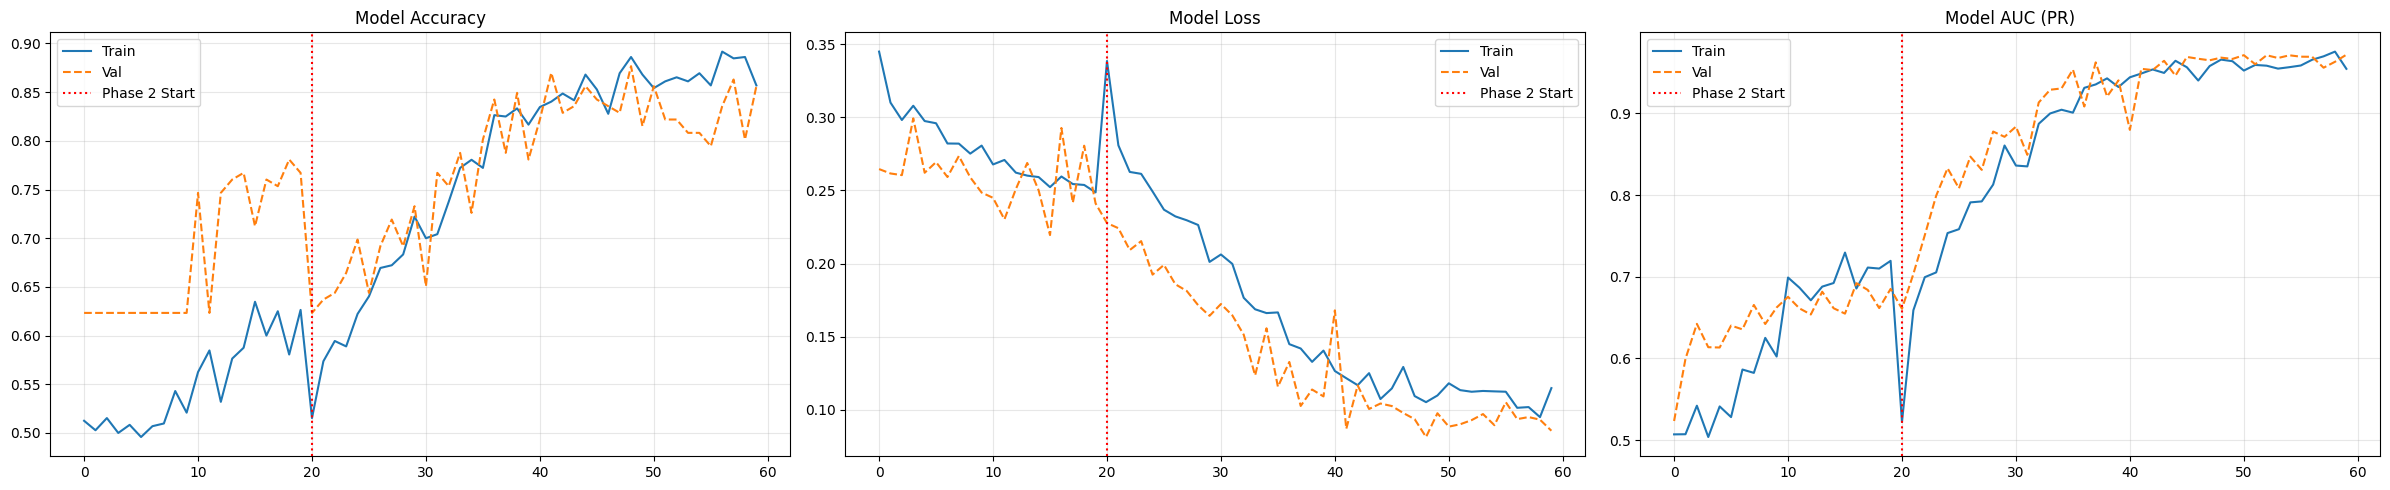

FINAL MODEL SUMMARY
Final Validation Accuracy : 85.62%
Final Validation AUC (PR) : 0.9717


In [21]:
# 11. CORRECTED TRAINING CURVES & SUMMARY


def merge_history(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

available_metrics = list(history_p2.history.keys())
precision_key = next((k for k in available_metrics if 'precision' in k), None)
auc_key = next((k for k in available_metrics if 'auc' in k), 'auc')

fig, axes = plt.subplots(1, 3, figsize=(24, 5))
metrics_to_plot = ['accuracy', 'loss', auc_key, precision_key]
titles = ['Model Accuracy', 'Model Loss', 'Model AUC (PR)']

for ax, key, title in zip(axes, metrics_to_plot, titles):
    if key:
        train_vals = merge_history(history_p1, history_p2, key)
        val_vals   = merge_history(history_p1, history_p2, f'val_{key}')
        
        ax.plot(train_vals, label='Train', color='#1f77b4')
        ax.plot(val_vals,   label='Val', linestyle='--', color='#ff7f0e')
        ax.axvline(x=20, color='red', linestyle=':', label='Phase 2 Start')
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f"{title} (Not Found)")

plt.tight_layout()
plt.show()

print("FINAL MODEL SUMMARY")


try:
    val_acc_list = merge_history(history_p1, history_p2, 'val_accuracy')
    val_auc_list = merge_history(history_p1, history_p2, f'val_{auc_key}')
    
    if precision_key:
        val_prec_list = merge_history(history_p1, history_p2, f'val_{precision_key}')
        final_prec = f"{val_prec_list[-1]*100:.2f}%"
    else:
        final_prec = "N/A"

    print(f"Final Validation Accuracy : {val_acc_list[-1]*100:.2f}%")
    print(f"Final Validation AUC (PR) : {val_auc_list[-1]:.4f}")
except Exception as e:
    print(f" Error extracting values: {e}")


In [27]:
# import cv2
# import numpy as np
# from IPython.display import Video, display

# def visualize_prediction(video_path, output_name='result.mp4', threshold=0.5):
#     # 1. تحميل الفيديو ومعالجته للنموذج
#     # نستخدم المولد (Generator) الذي أنشأناه سابقاً لضمان نفس المعالجة (RGB + Motion)
#     temp_gen = VideoDataGenerator([video_path], [0], batch_size=1, augment=False, shuffle=False)
#     X, _ = temp_gen[0]
    
#     # 2. التوقع باستخدام النموذج
#     prediction_prob = model.predict(X, verbose=0)[0][0]
#     is_shoplifting = prediction_prob > threshold
#     label = "SHOPLIFTING" if is_shoplifting else "NORMAL"
#     conf_text = f"{prediction_prob*100:.2f}%"
#     color = (0, 0, 255) if is_shoplifting else (0, 255, 0) # أحمر للسرقة، أخضر للطبيعي

#     # 3. كتابة النتيجة على الفيديو الأصلي وحفظه
#     cap = cv2.VideoCapture(video_path)
#     width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
#     height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
#     fps    = cap.get(cv2.CAP_PROP_FPS)
    
#     fourcc = cv2.VideoWriter_fourcc(*'mp4v')
#     out = cv2.VideoWriter(output_name, fourcc, fps, (width, height))

#     while cap.isOpened():
#         ret, frame = cap.read()
#         if not ret: break
        
#         # إضافة مستطيل خلفية للنص للقراءة بوضوح
#         cv2.rectangle(frame, (10, 10), (350, 80), (0,0,0), -1)
#         # كتابة التصنيف ونسبة الثقة
#         cv2.putText(frame, f"STATUS: {label}", (20, 40), 
#                     cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
#         cv2.putText(frame, f"CONFIDENCE: {conf_text}", (20, 70), 
#                     cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        
#         out.write(frame)
        
#     cap.release()
#     out.release()
#     print(f" Video saved as: {output_name}")
#     return output_name

# # اختاري فيديو عشوائي من الـ Test Set التي فصلناها سابقاً
# test_video_path = test_v[20] # يمكنك تغيير الرقم لتجربة فيديوهات مختلفة
# output_file = visualize_prediction(test_video_path)


# print(f"Displaying result for: {test_video_path}")

In [26]:
import cv2
import os
from IPython.display import Video, display

def visualize_and_display_prediction(video_path, threshold=0.5):

    # تحضير اسم الملف المؤقت (الوسيط)
    base_name = os.path.basename(video_path).split('.')[0]
    temp_output = f'tmp_{base_name}.mp4'
    final_output = f'result_{base_name}.mp4'
    
    # أ. تحميل الفيديو ومعالجته للنموذج باستخدام الـ Generator الأصلي
    # (RGB + Motion diff) لضمان دقة النتائج
    temp_gen = VideoDataGenerator([video_path], [0], batch_size=1, augment=False, shuffle=False)
    X, _ = temp_gen[0]
    
    # ب. التوقع باستخدام النموذج
    prediction_prob = model.predict(X, verbose=0)[0][0]
    is_shoplifting = prediction_prob > threshold
    
    # تحديد النص واللون بناءً على النتيجة
    if is_shoplifting:
        status_label = "SHOPLIFTING"
        text_color = (0, 0, 255) # أحمر للسرقة (BGR)
    else:
        status_label = "NORMAL"
        text_color = (0, 255, 0) # أخضر للطبيعي (BGR)
        
    conf_text = f"({prediction_prob*100:.1f}% Confidence)"
    
    # ج. كتابة النتيجة على الفيديو الأصلي وحفظه في ملف مؤقت
    cap = cv2.VideoCapture(video_path)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    
    # نستخدم MP4V كصيغة وسيطة سريعة للكتابة
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(temp_output, fourcc, fps, (width, height))

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        
        # إضافة مستطيل خلفية للنص للقراءة بوضوح
        cv2.rectangle(frame, (10, 10), (height-10, 120), (0,0,0), -1)
        
        # كتابة التصنيف (Normal أو Not Normal)
        cv2.putText(frame, f"STATUS: {status_label}", (25, 60), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, text_color, 4)
        
        # كتابة نسبة الثقة
        cv2.putText(frame, f"INFO: {conf_text}", (25, 100), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
        
        out.write(frame)
        
    cap.release()
    out.release()
    
    # د. تحويل الفيديو المؤقت لصيغة H264 لظهوره في Kaggle
    # نستخدم ffmpeg (متاح تلقائياً في Kaggle/Google Colab)
    print(f"Done labeling. Converting {temp_output} to browser-friendly H264...")
    os.system(f'ffmpeg -y -i {temp_output} -vcodec libx264 -f mp4 {final_output} > /dev/null 2>&1')
    
    # حذف الملف المؤقت
    if os.path.exists(temp_output):
        os.remove(temp_output)
        
    return final_output, status_label


# اختاري أي فيديو من الـ Test Set التي قمنا بفصلها (test_v)
# فيديو رقم 10 على سبيل المثال
example_video = test_v[5] 

# تشغيل الـ Inference والحصول على الفيديو المكتوب عليه
processed_video, predicted_class = visualize_and_display_prediction(example_video)

# عرض الفيديو مباشرة في الـ Output في Kaggle
print(f"\nResult for: {os.path.basename(example_video)}")
print(f" Predicted Class: {predicted_class}")

# عرض الفيديو
display(Video(processed_video, embed=True, width=700, height=400))

Done labeling. Converting tmp_shop_lifter_n_108.mp4 to browser-friendly H264...

Result for: shop_lifter_n_108.mp4
 Predicted Class: NORMAL
